<a href="https://colab.research.google.com/github/jonitodev/PembelajaranMesin/blob/main/JS05/JS05_02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# JS05_02 — Naive Bayes


## Persiapan

Jika library belum terpasang, hapus `#` pada baris `%pip` lalu jalankan.

In [1]:
# %pip install numpy pandas scikit-learn matplotlib seaborn

In [2]:
get_ipython().run_line_magic('matplotlib', 'inline')
from pathlib import Path
import platform
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
from IPython.display import display, Markdown
from sklearn.datasets import make_classification
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, GridSearchCV, cross_validate
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import MultinomialNB, GaussianNB
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, precision_score, recall_score,
    f1_score, classification_report, ConfusionMatrixDisplay
)

sns.set_theme(style='whitegrid', palette='colorblind')
plt.rcParams.update({'figure.figsize': (8, 4.5), 'figure.dpi': 110})
pd.set_option('display.max_columns', 25)
pd.set_option('display.precision', 4)

### Fungsi evaluasi

Untuk menampilkan akurasi dan confusion matrix.

In [3]:
def evaluasi_model(model, X_train, X_test, y_train, y_test, nama, labels=None):
    pred_train = model.predict(X_train)
    pred_test = model.predict(X_test)
    hasil = {
        'Model': nama,
        'Akurasi train': accuracy_score(y_train, pred_train),
        'Akurasi test': accuracy_score(y_test, pred_test),
        'F1 makro': f1_score(y_test, pred_test, average='macro', zero_division=0),
        'Balanced accuracy': balanced_accuracy_score(y_test, pred_test),
    }
    display(pd.DataFrame([hasil]).set_index('Model'))
    print(classification_report(y_test, pred_test, labels=labels, zero_division=0))
    fig, ax = plt.subplots(figsize=(5.4, 4.2))
    ConfusionMatrixDisplay.from_predictions(
        y_test, pred_test, labels=labels, cmap='Blues', colorbar=False, ax=ax
    )
    ax.set(title=nama, xlabel='Prediksi', ylabel='Label sebenarnya')
    plt.tight_layout()
    plt.show()
    return hasil

## Membuat data

Dibuat 30 sampel dengan dua fitur dan dua kelas. Nilai diubah menjadi bilangan bulat tidak negatif untuk contoh MultinomialNB.

Seed ditetapkan agar hasil bisa diulang; angkanya bisa berbeda dari modul.

[Sumber praktikum](https://polinema.gitbook.io/jti-modul-praktikum-pembelajaran-mesin-mah/js05-klasifikasi-1/lab-2)

In [4]:
dummy_X_raw, dummy_y = make_classification(
    n_samples=30, n_features=2, n_classes=2, n_informative=2,
    n_redundant=0, n_repeated=0, shuffle=False, random_state=42
)
# Pembulatan terakhir mencegah 28.999999... terpotong menjadi 28 saat casting.
dummy_X = np.rint(np.round(np.abs(dummy_X_raw), 2) * 100).astype(int)
assert dummy_X.min() >= 0
dummy_df = pd.DataFrame(dummy_X, columns=['Fitur 1', 'Fitur 2'])
dummy_df['Label'] = dummy_y
dummy_labeled = dummy_df.copy()
dummy_labeled['Label'] = dummy_labeled['Label'].map({1: 'Kelas A', 0: 'Kelas B'})
print('Fitur:')
print(dummy_X)
print('Target:', dummy_y)
display(dummy_df.head())
display(dummy_labeled.head())

Fitur:
[[112 139]
 [179 210]
 [ 83  71]
 [182 265]
 [105  78]
 [ 67  43]
 [ 36  54]
 [ 20  70]
 [122  70]
 [251  83]
 [ 50 142]
 [207 110]
 [116  84]
 [124  66]
 [150  85]
 [ 16  73]
 [ 46 114]
 [ 26  80]
 [ 18 115]
 [211 154]
 [ 53  66]
 [ 93 109]
 [175 172]
 [ 80  85]
 [111 125]
 [116 105]
 [ 66  92]
 [160  85]
 [ 53 106]
 [122  85]]
Target: [0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0 1 1 1 1 1 1 1]


,Fitur 1,Fitur 2,Label
0,112,139,0
1,179,210,0
2,83,71,0
3,182,265,0
4,105,78,0


,Fitur 1,Fitur 2,Label
0,112,139,Kelas B
1,179,210,Kelas B
2,83,71,Kelas B
3,182,265,Kelas B
4,105,78,Kelas B


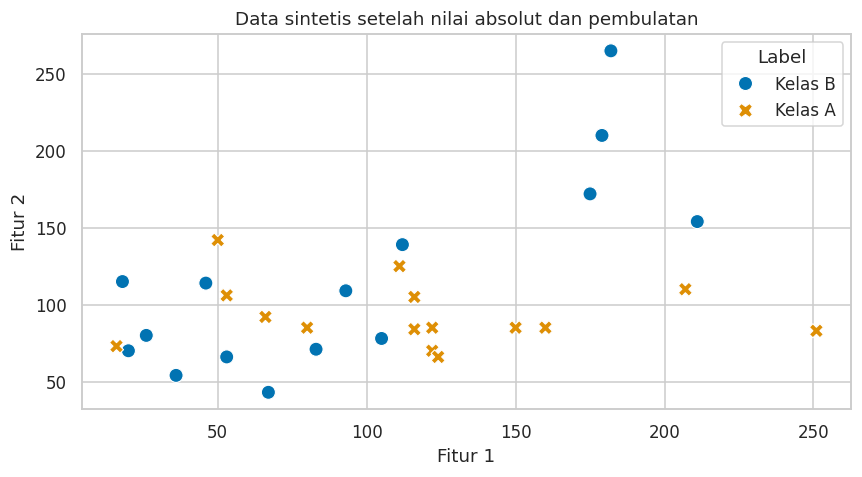

In [5]:
sns.scatterplot(data=dummy_labeled, x='Fitur 1', y='Fitur 2',
                hue='Label', style='Label', s=85)
plt.title('Data sintetis setelah nilai absolut dan pembulatan')
plt.tight_layout()
plt.show()

### Membandingkan dua model

MultinomialNB dan GaussianNB memakai pembagian data yang sama: 70% latih dan 30% uji.

Train: 21 | Test: 9


,Akurasi train,Akurasi test,F1 makro,Balanced accuracy
Model,,,,
MultinomialNB,0.8095,0.3333,0.325,0.5714


              precision    recall  f1-score   support

           0       0.25      1.00      0.40         2
           1       1.00      0.14      0.25         7

    accuracy                           0.33         9
   macro avg       0.62      0.57      0.33         9
weighted avg       0.83      0.33      0.28         9



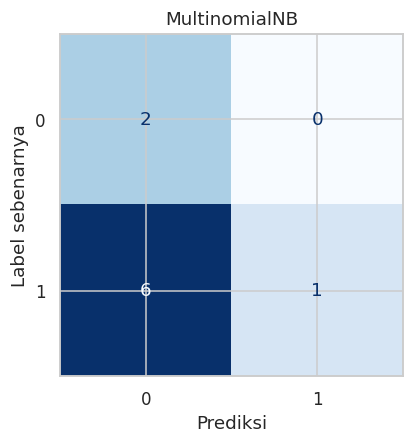

,Akurasi train,Akurasi test,F1 makro,Balanced accuracy
Model,,,,
GaussianNB,0.8571,0.4444,0.4444,0.6429


              precision    recall  f1-score   support

           0       0.29      1.00      0.44         2
           1       1.00      0.29      0.44         7

    accuracy                           0.44         9
   macro avg       0.64      0.64      0.44         9
weighted avg       0.84      0.44      0.44         9



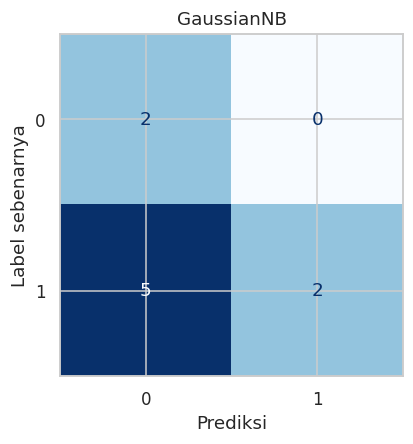

,Akurasi train,Akurasi test,F1 makro,Balanced accuracy
Model,,,,
MultinomialNB,0.8095,0.3333,0.3250,0.5714
GaussianNB,0.8571,0.4444,0.4444,0.6429


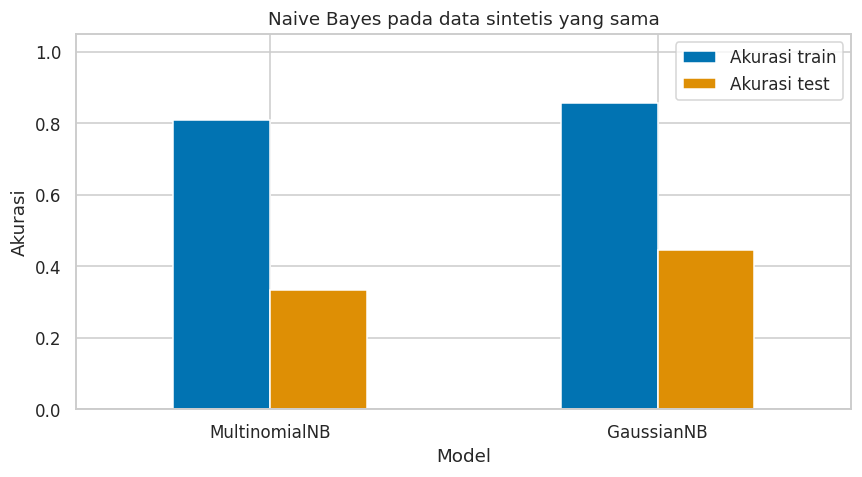

In [6]:
dummy_X_train, dummy_X_test, dummy_y_train, dummy_y_test = train_test_split(
    dummy_X, dummy_y, test_size=0.30, random_state=30
)
print(f'Train: {len(dummy_y_train)} | Test: {len(dummy_y_test)}')
dummy_models = {
    'MultinomialNB': MultinomialNB(),
    'GaussianNB': GaussianNB()
}
dummy_results = []
for dummy_name, dummy_model in dummy_models.items():
    dummy_model.fit(dummy_X_train, dummy_y_train)
    dummy_results.append(evaluasi_model(
        dummy_model, dummy_X_train, dummy_X_test, dummy_y_train, dummy_y_test,
        dummy_name, labels=[0, 1]
    ))
dummy_result = pd.DataFrame(dummy_results).set_index('Model')
display(dummy_result)
dummy_result[['Akurasi train', 'Akurasi test']].plot.bar(rot=0)
plt.ylabel('Akurasi')
plt.ylim(0, 1.05)
plt.title('Naive Bayes pada data sintetis yang sama')
plt.tight_layout()
plt.show()

In [7]:
dummy_top_acc = dummy_result['Akurasi test'].max()
dummy_top_names = dummy_result.index[
    np.isclose(dummy_result['Akurasi test'], dummy_top_acc)
].tolist()
display(Markdown(
    f"**Kesimpulan:** {', '.join(dummy_top_names)} mendapat akurasi uji tertinggi, "
    f"yaitu {dummy_top_acc:.2%}. Data uji hanya 9 sampel, jadi hasilnya "
    "belum cukup untuk menyatakan model ini selalu lebih baik."
))

**Kesimpulan:** GaussianNB mendapat akurasi uji tertinggi, yaitu 44.44%. Data uji hanya 9 sampel, jadi hasilnya belum cukup untuk menyatakan model ini selalu lebih baik.